In [7]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
#pd.set_option('max_columns', 200)

In [4]:
df = pd.read_csv('pros.csv')

In [6]:
df.head

<bound method NDFrame.head of       ID  CAPSULE  AGE  RACE  DPROS  DCAPS   PSA   VOL  GLEASON
0      1        0   65   1.0      2      1   1.4   0.0        6
1      2        0   72   1.0      3      2   6.7   0.0        7
2      3        0   70   1.0      1      2   4.9   0.0        6
3      4        0   76   2.0      2      1  51.2  20.0        7
4      5        0   69   1.0      1      1  12.3  55.9        6
..   ...      ...  ...   ...    ...    ...   ...   ...      ...
375  376        0   58   2.0      3      1  18.2  28.6        7
376  377        0   69   2.0      1      1   7.9  14.6        5
377  378        1   76   1.0      2      1   5.5  53.9        8
378  379        0   69   2.0      2      1   1.5   8.6        5
379  380        0   69   1.0      2      1   1.9  20.7        6

[380 rows x 9 columns]>

In [5]:
df.shape

(380, 9)

In [8]:
df.columns

Index(['ID', 'CAPSULE', 'AGE', 'RACE', 'DPROS', 'DCAPS', 'PSA', 'VOL',
       'GLEASON'],
      dtype='object')

In [9]:
df.dtypes

ID           int64
CAPSULE      int64
AGE          int64
RACE       float64
DPROS        int64
DCAPS        int64
PSA        float64
VOL        float64
GLEASON      int64
dtype: object

In [10]:
df.describe()

,ID,CAPSULE,AGE,RACE,DPROS,DCAPS,PSA,VOL,GLEASON
count,380.000000,380.000000,380.000000,377.000000,380.000000,380.000000,380.000000,379.000000,380.000000
mean,190.500000,0.402632,66.039474,1.095491,2.271053,1.107895,15.408632,15.854644,6.384211
std,109.840794,0.491074,6.527071,0.294282,1.000108,0.310656,19.997573,18.353814,1.091953
min,1.000000,0.000000,43.000000,1.000000,1.000000,1.000000,0.300000,0.000000,0.000000
25%,95.750000,0.000000,62.000000,1.000000,1.000000,1.000000,5.000000,0.000000,6.000000
50%,190.500000,0.000000,67.000000,1.000000,2.000000,1.000000,8.750000,14.300000,6.000000
75%,285.250000,1.000000,71.000000,1.000000,3.000000,1.000000,17.125000,26.500000,7.000000
max,380.000000,1.000000,79.000000,2.000000,4.000000,2.000000,139.700000,97.600000,9.000000


In [11]:
df.head()

,ID,CAPSULE,AGE,RACE,DPROS,DCAPS,PSA,VOL,GLEASON
0,1,0,65,1.0,2,1,1.4,0.0,6
1,2,0,72,1.0,3,2,6.7,0.0,7
2,3,0,70,1.0,1,2,4.9,0.0,6
3,4,0,76,2.0,2,1,51.2,20.0,7
4,5,0,69,1.0,1,1,12.3,55.9,6


In [55]:
df.isna().sum()

ID         0
CAPSULE    0
AGE        0
RACE       3
DPROS      0
DCAPS      0
PSA        0
VOL        1
GLEASON    0
dtype: int64

In [58]:
null_vol = df[df['VOL'].isnull()]
print(null_vol)

      ID  CAPSULE  AGE  RACE  DPROS  DCAPS  PSA  VOL  GLEASON
325  326        0   69   1.0      1      1  6.3  NaN        5


In [60]:
null_race = df[df['RACE'].isnull()]
print(null_race)

      ID  CAPSULE  AGE  RACE  DPROS  DCAPS   PSA   VOL  GLEASON
21    22        1   70   NaN      4      1  67.1   0.0        7
45    46        1   75   NaN      3      2  33.0  15.2        8
251  252        0   43   NaN      2      1   3.8  21.0        6


In [136]:
vol_average = df['VOL'].mean()
df['VOL'] = df['VOL'].fillna(vol_average)
print(df['VOL'].isna().sum())

0


In [17]:
df.loc[df.duplicated()]

,ID,CAPSULE,AGE,RACE,DPROS,DCAPS,PSA,VOL,GLEASON


In [19]:
df.loc[df.duplicated(subset=['ID'])]

,ID,CAPSULE,AGE,RACE,DPROS,DCAPS,PSA,VOL,GLEASON


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       380 non-null    int64  
 1   CAPSULE  380 non-null    int64  
 2   AGE      380 non-null    int64  
 3   RACE     377 non-null    float64
 4   DPROS    380 non-null    int64  
 5   DCAPS    380 non-null    int64  
 6   PSA      380 non-null    float64
 7   VOL      379 non-null    float64
 8   GLEASON  380 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 26.8 KB


In [34]:
df['AGE'].value_counts()

AGE
70    29
68    28
65    24
71    24
66    23
69    23
62    20
64    17
67    16
73    15
75    14
74    13
59    13
61    13
72    13
63    11
54    10
58    10
57    10
60     9
76     9
56     7
78     5
55     5
77     4
53     4
51     3
79     2
50     2
52     2
47     1
43     1
Name: count, dtype: int64

In [35]:
df['GLEASON'].value_counts()

GLEASON
6    139
7    128
5     67
8     30
9     13
0      2
4      1
Name: count, dtype: int64

In [36]:
df['DPROS'].value_counts()

DPROS
2    132
1     99
3     96
4     53
Name: count, dtype: int64

In [24]:
df.columns

Index(['ID', 'CAPSULE', 'AGE', 'RACE', 'DPROS', 'DCAPS', 'PSA', 'VOL',
       'GLEASON'],
      dtype='object')

In [131]:
df['RACE'].value_counts(normalize=True)

RACE
1.0    0.904509
2.0    0.095491
Name: proportion, dtype: float64

In [132]:
df['RACE'].value_counts()

RACE
1.0    341
2.0     36
Name: count, dtype: int64

In [28]:
df['GLEASON'].value_counts()

GLEASON
6    139
7    128
5     67
8     30
9     13
0      2
4      1
Name: count, dtype: int64

In [ ]:
df['RACE'].value_counts(normalize=True)

Visulaizations

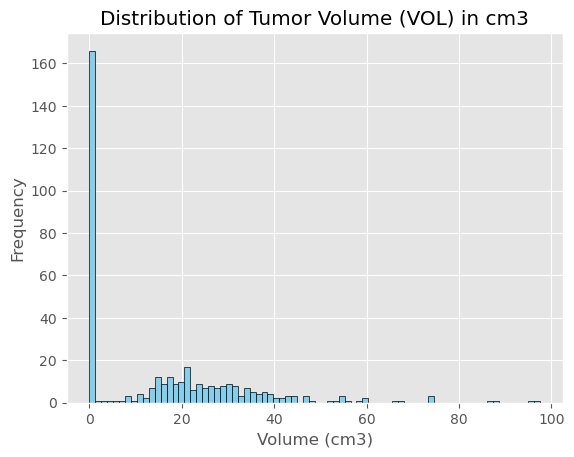

In [130]:
vol = df['VOL'].plot(
    kind='hist', 
    bins=76, 
    color='skyblue',      
    edgecolor='black',     
    title='Distribution of Tumor Volume (VOL) in cm3', 
    xlabel='Volume (cm3)',        
    ylabel='Frequency'              
);
fig = vol.get_figure()
fig.savefig('vol_hist.png', dpi=300, bbox_inches='tight') 

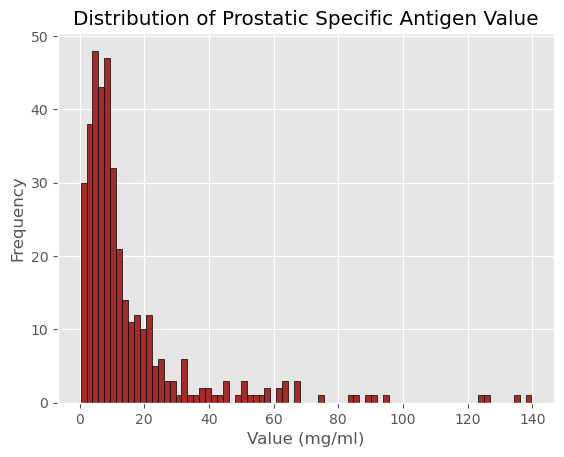

In [119]:
psa = df['PSA'].plot(
    kind='hist', 
    bins=76, 
    color='brown',      
    edgecolor='black',     
    title='Distribution of Prostatic Specific Antigen Value', 
    xlabel='Value (mg/ml)',        
    ylabel='Frequency'              
);
fig2 = psa.get_figure()
fig2.savefig('psa_hist.png', dpi=300, bbox_inches='tight');

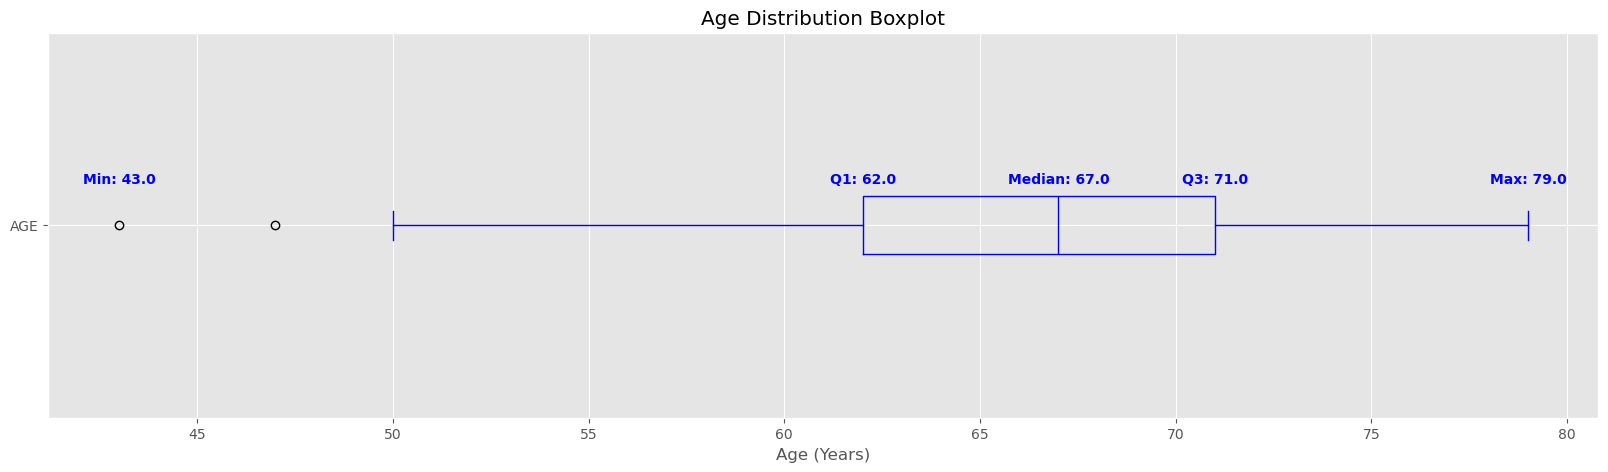

In [137]:
age = df['AGE'].plot(kind='box', color='blue', vert=False, figsize=(20, 5))
stats = df['AGE'].describe()
labels = {
    'Min': stats['min'],
    'Q1': stats['25%'],
    'Median': stats['50%'],
    'Q3': stats['75%'],
    'Max': stats['max']
}
for text, value in labels.items():
    age.text(value, 1.1, f'{text}: {value:.1f}', 
            ha='center', va='bottom', fontweight='bold', color='blue')

age.set_title("Age Distribution Boxplot")
age.set_xlabel("Age (Years)")
fig3 = age.get_figure()
fig3.savefig('age_boxplot.png', dpi=300, bbox_inches='tight');

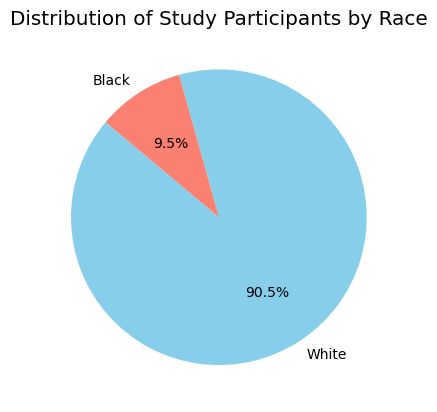

In [121]:
race_names = {1.0: 'White', 2.0: 'Black'}
race = df['RACE'].map(race_names).value_counts()
races = race.plot(
    kind='pie',
    autopct='%1.1f%%',      
    startangle=140,          
    colors=['skyblue', 'salmon'], # Custom colors
    title='Distribution of Study Participants by Race',
    ylabel=''                
)
fig4 = races.get_figure()
fig4.savefig('race_pie.png', dpi=300, bbox_inches='tight');

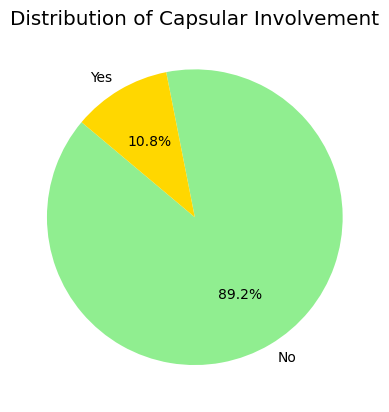

In [122]:
dcaps_names = {1.0: 'No', 2.0: 'Yes'}
ci = df['DCAPS'].map(dcaps_names).value_counts()
dcaps = ci.plot(
    kind='pie',
    autopct='%1.1f%%',       
    startangle=140,         
    colors=[ 'lightgreen', 'gold'], # Custom colors
    title='Distribution of Capsular Involvement',
    ylabel=''                
)
fig5 = dcaps.get_figure()
fig5.savefig('dcaps_pie.png', dpi=300, bbox_inches='tight');

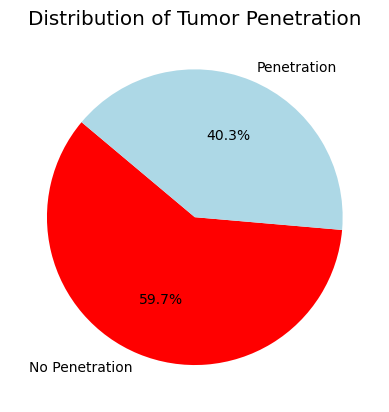

In [123]:
capsule_names = {0.0: 'No Penetration', 1.0: 'Penetration'}
tp = df['CAPSULE'].map(capsule_names).value_counts()
capsule = tp.plot(
    kind='pie',
    autopct='%1.1f%%',      
    startangle=140,         
    colors=[ 'red', 'lightblue'], 
    title='Distribution of Tumor Penetration',
    ylabel=''                
)
fig6 = capsule.get_figure()
fig6.savefig('capsules_pie.png', dpi=300, bbox_inches='tight');

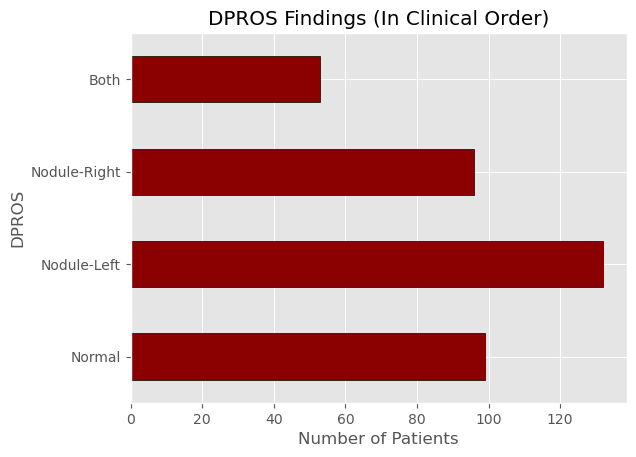

In [126]:
dpros_map = {1: 'Normal', 2: 'Nodule-Left', 3: 'Nodule-Right', 4: 'Both'}
desired_order = ['Normal', 'Nodule-Left', 'Nodule-Right', 'Both']
dpros_counts = df['DPROS'].map(dpros_map).value_counts().reindex(desired_order)
ax = dpros_counts.plot(
    kind='barh', 
    color='darkred', 
    edgecolor='black',
    title='DPROS Findings (In Clinical Order)',
    xlabel='Number of Patients'
)
fig7 = ax.get_figure()
fig7.savefig('dpros_ordered.png', dpi=300, bbox_inches='tight')

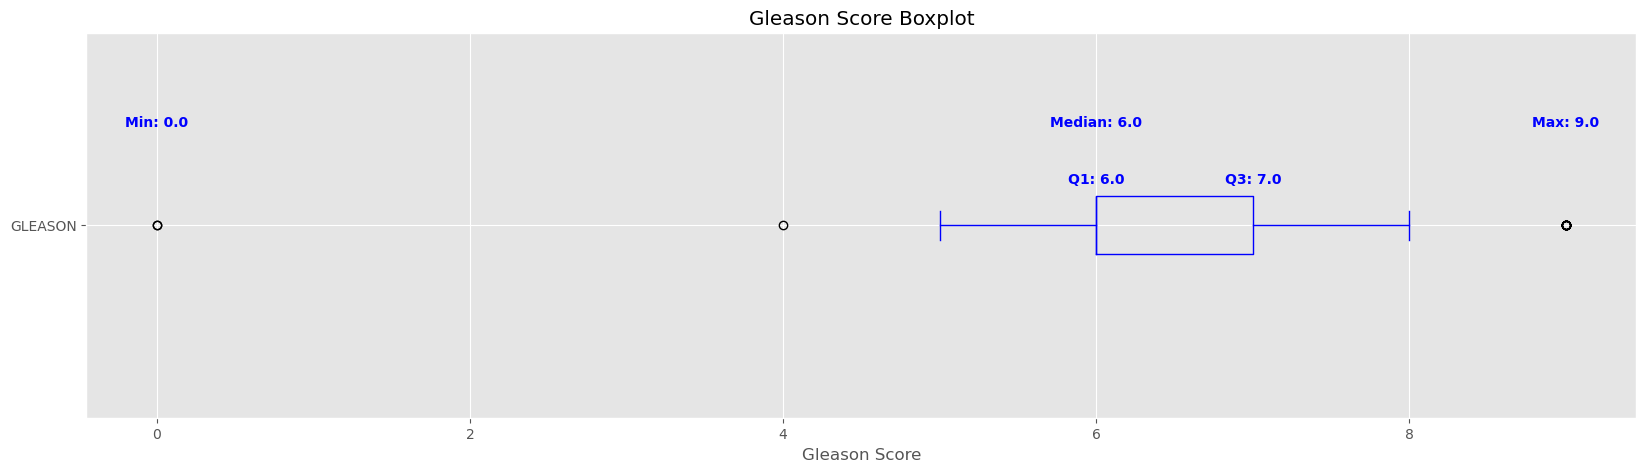

In [129]:
gleason = df['GLEASON'].plot(kind='box', color='blue', vert=False, figsize=(20, 5))
stat = df['GLEASON'].describe()
labels = {
    'Min': stat['min'],
    'Q1': stat['25%'],
    'Median': stat['50%'],
    'Q3': stat['75%'],
    'Max': stat['max']
}
for i, (text, value) in enumerate(labels.items()):
     y_pos = 1.25 if i % 2 == 0 else 1.1
    gleason.text(value, y_pos, f'{text}: {value:.1f}', 
                ha='center', va='bottom', fontweight='bold', color='blue')
gleason.set_ylim(0.5, 1.5) 

gleason.set_title("Gleason Score Boxplot")
gleason.set_xlabel("Gleason Score") 
fig8 = gleason.get_figure()
fig8.savefig('gleason_boxplot.png', dpi=300, bbox_inches='tight')